# 簡易ネットワーク

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

def normalized_cut(similarity_matrix: np.ndarray):
    '''
    Calculate the normalized cut of the graph using the similarity matrix
    
    Parameters
    ----------
    similarity_matrix: np.ndarray
        The similarity matrix of the graph
    
    Returns
    -------
    best_partition: np.ndarray
        The resulting partition of the graph
    
    Notes
    -----
    The normalized cut is calculated by solving the (generalized) eigenvalue problem of the Laplacian matrix and the degree matrix.
    Please read the paper "Normalized Cuts and Image Segmentation" by Shi and Malik (2000) for more details.
    '''
    # weighted degree matrix D
    D = np.diag(np.sum(similarity_matrix, axis=1))
    # Laplacian matrix L
    L = D - similarity_matrix
    # Add a small value to the diagonal of D to avoid division by zero
    D += np.eye(D.shape[0]) * 1e-10
    
    # Solve the generalized eigenvalue problem Lu = lambda D u
    _, eigvec = scipy.linalg.eigh(L, D) # eigh is used for the eigenvalue problem of symmetric matrices
    y = eigvec[:,1]
    
    '''
    # Solve the normalized eigenvalue problem L_norm y = lambda y
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D)))
    L_norm = D_inv_sqrt @ L @ D_inv_sqrt
    _, eigvec = scipy.linalg.eigh(L_norm)
    y = np.diag(np.sqrt(np.diag(D))) @ np.array(eigvec[:,1])
    '''
    
    '''
    # Lanczos method for sparse matrix
    D_inv_sqrt = csr_matrix(np.diag(1.0 / np.sqrt(np.diag(D))))
    D_sqrt = csr_matrix(np.diag(np.sqrt(np.diag(D))))
    L_norm = D_inv_sqrt @ L @ D_inv_sqrt
    engine = PyLanczos(L_norm, False, 2) # Find 2 minimum eigenpair (False: minimum, True: maximum)
    _, eigvec = engine.run()
    y = D_sqrt @ eigvec[1]
    '''
    
    # find the best partition that minimizes the normalized cut
    parition_points = np.linspace(y.min(), y.max(), 100)
    min_Ncut = np.inf
    for point in parition_points:
        # calculate the Ncut between cluster A and B
        A = y <= point
        B = y > point
        cutAB = similarity_matrix[A, :][:, B].sum()
        cutAV = similarity_matrix[A, :].sum()
        cutBV = similarity_matrix[B, :].sum()
        Ncut = np.inf if cutAV == 0 or cutBV == 0 else cutAB / cutAV + cutAB / cutBV
        if Ncut < min_Ncut:
            min_Ncut = Ncut
            best_partition = A
    
    return best_partition

def find_adjacent_clusters(clusters: list, graph: nx.Graph):
    '''
    Find the adjacent clusters of each cluster in the graph
    
    Parameters
    ----------
    clusters: list
        The list of clusters of the graph (each cluster is a list of nodes)
    graph: nx.Graph
        The graph object of the network
    
    Returns
    -------
    cluster_adjacency: dict
        The dictionary of the adjacent clusters of each cluster
    '''
    cluster_adjacency = {}
    for i, cluster in enumerate(clusters):
        cluster_adjacency[i] = set()
        for node in cluster:
            for neighbor in graph.neighbors(node):
                for j, other_cluster in enumerate(clusters):
                    if j != i and neighbor in other_cluster:
                        cluster_adjacency[i].add(j)
    return cluster_adjacency

def calculate_NSk(A: list, B: list, S: nx.Graph):
    '''
    Calculate the NS_k(A, B) of the cluster A and B
    
    Parameters
    ----------
    A: list
        The list of nodes in cluster A
    B: list
        The list of nodes in cluster B
    node_density: dict
        The dictionary of the density of each node in the line graph (density of the edge in the original graph)
    
    Returns
    -------
    NSk_A: float
    '''
    
    # クラスタAとBの密度リストを取得
    
    densities_A = np.array([S.nodes[node]['density'] for node in A])
    densities_B = np.array([S.nodes[node]['density'] for node in B])
    
    # クラスタAとBの平均密度を計算
    u_A = np.mean(densities_A)
    u_B = np.mean(densities_B)
    
    # クラスタAとBの分散を計算
    var_A = np.var(densities_A)
    var_B = np.var(densities_B)
    
    # NS_k(A)を計算
    NSk_A = (2 * var_A) / (var_A + var_B + (u_A - u_B) ** 2)
    
    return NSk_A

def calculate_NSk_total(clusters: list, S: nx.Graph):
    total_NSk = 0
    for i, A in enumerate(clusters):
        min_NSk = np.inf
        adjacent_clusters = find_adjacent_clusters(clusters, S)[i]
        if len(adjacent_clusters) == 0:
            continue
        else:
            for j, B in enumerate(clusters):
                if j in adjacent_clusters:
                    NSk_A = calculate_NSk(A, B, S)
                    if NSk_A < min_NSk:
                        min_NSk = NSk_A
            total_NSk += min_NSk
    total_NSk /= len(clusters)
    return total_NSk



def recursive_bipartition(graph: nx.Graph, num_desired_clusters: int, threshold: int):
    '''
    Recursively bipartition the graph until the desired number of clusters is reached
    
    Parameters
    ----------
    graph: nx.Graph
        The graph object of the network
    num_desired_clusters: int
        The number of clusters to be created
    threshold: int
        The threshold for the similarity calculation. 
        If the threshold is 1, the similarity is based on the adjacent edges. 
        Otherwise, the similarity is based on the shortest path between edges.
    
    Returns
    -------
    best_clusters: list
        The best clusters based on the normalized cut
    max_clusters: list
        The clusters with the maximum number of clusters
    '''
    clusters = []
    clusters_dict = {}
    NS_dict = {}
    nodes_to_partition = list(graph.nodes)
    if threshold > 1:
        # 全ペア間の最短経路長を計算
        shortest_paths = calculate_all_pairs_shortest_paths(G)
        similarity_matrix = create_similarity_matrix(S, shortest_paths, threshold)
        # ヒストグラム
        plt.hist(similarity_matrix[similarity_matrix>0].flatten(), bins=100, range=(0, 1))
        plt.title('Histogram of Similarity index')
        plt.show()
    
    def bipartition_and_recurse(nodes):
        if len(clusters) >= num_desired_clusters:
            return
        subgraph = graph.subgraph(nodes)
        # 隣接行列を取得（重みを含む）
        weighted_adj_matrix = nx.adjacency_matrix(subgraph, weight='weight').todense()
        idx = [i for i, node in enumerate(nodes)]
        if threshold > 1:
            sub_similarity_matrix = similarity_matrix[idx,:][:, idx]
        elif threshold == 1:
            sub_similarity_matrix = weighted_adj_matrix
        else:
            raise ValueError("Threshold must be greater than 0")
        
        partition = normalized_cut(sub_similarity_matrix)
        
        part_A = [node for i, node in enumerate(subgraph.nodes) if partition[i]]
        part_B = [node for i, node in enumerate(subgraph.nodes) if not partition[i]]
        
        clusters.append(part_A)
        clusters.append(part_B)
        
        # NSを計算
        NS = calculate_NSk_total(clusters, graph)
        print("クラスタ数:", len(clusters))
        print("NS:", NS)
        NS_dict[len(clusters)] = NS
        clusters_dict[len(clusters)] = list(clusters) # deep copy
        print("clusters_dict:", clusters_dict)
        
        if len(clusters) < num_desired_clusters:
            largest_cluster = max(clusters, key=len)
            clusters.remove(largest_cluster)
            bipartition_and_recurse(largest_cluster)
    
    bipartition_and_recurse(nodes_to_partition)
    print("NS_dict:", NS_dict)
    best_clusters = clusters_dict[min(NS_dict, key=NS_dict.get)]
    max_clusters = clusters_dict[len(clusters_dict)]
    
    return best_clusters, max_clusters, clusters_dict

Number of nodes in the networkx graph: 16
Number of edges in the networkx graph: 20
weight mean: 0.4565615901936252
weight std: 0.434595122234355


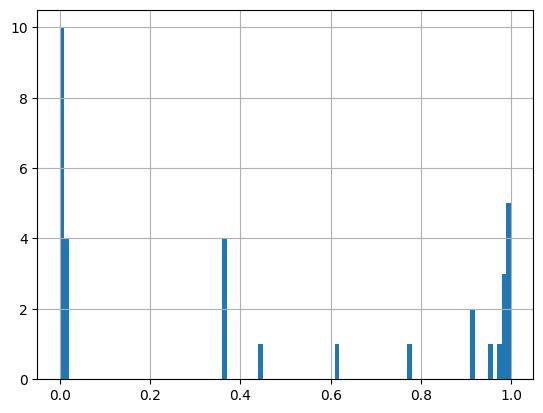

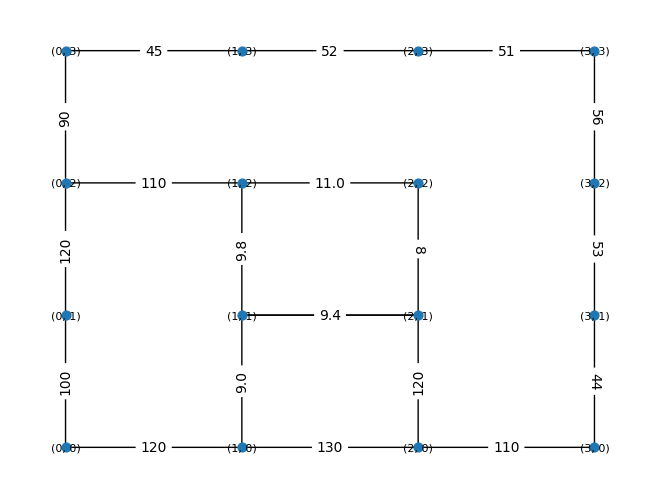

クラスタ数: 2
NS: 0.15078724182409772
clusters_dict: {2: [[((1, 0), (1, 1), 0), ((1, 1), (1, 2), 0), ((1, 1), (2, 1), 0), ((2, 2), (2, 1), 0), ((1, 1), (2, 1), 1), ((1, 2), (2, 2), 0)], [((2, 0), (2, 1), 0), ((0, 1), (0, 2), 0), ((0, 2), (0, 3), 0), ((0, 0), (0, 1), 0), ((0, 2), (1, 2), 0), ((3, 2), (3, 1), 0), ((3, 1), (3, 0), 0), ((3, 0), (2, 0), 0), ((2, 0), (1, 0), 0), ((0, 0), (1, 0), 0), ((0, 3), (1, 3), 0), ((1, 3), (2, 3), 0), ((2, 3), (3, 3), 0), ((3, 3), (3, 2), 0)]]}
クラスタ数: 3
NS: 0.011969917378982673
clusters_dict: {2: [[((1, 0), (1, 1), 0), ((1, 1), (1, 2), 0), ((1, 1), (2, 1), 0), ((2, 2), (2, 1), 0), ((1, 1), (2, 1), 1), ((1, 2), (2, 2), 0)], [((2, 0), (2, 1), 0), ((0, 1), (0, 2), 0), ((0, 2), (0, 3), 0), ((0, 0), (0, 1), 0), ((0, 2), (1, 2), 0), ((3, 2), (3, 1), 0), ((3, 1), (3, 0), 0), ((3, 0), (2, 0), 0), ((2, 0), (1, 0), 0), ((0, 0), (1, 0), 0), ((0, 3), (1, 3), 0), ((1, 3), (2, 3), 0), ((2, 3), (3, 3), 0), ((3, 3), (3, 2), 0)]], 3: [[((1, 0), (1, 1), 0), ((1, 1), (1, 2), 

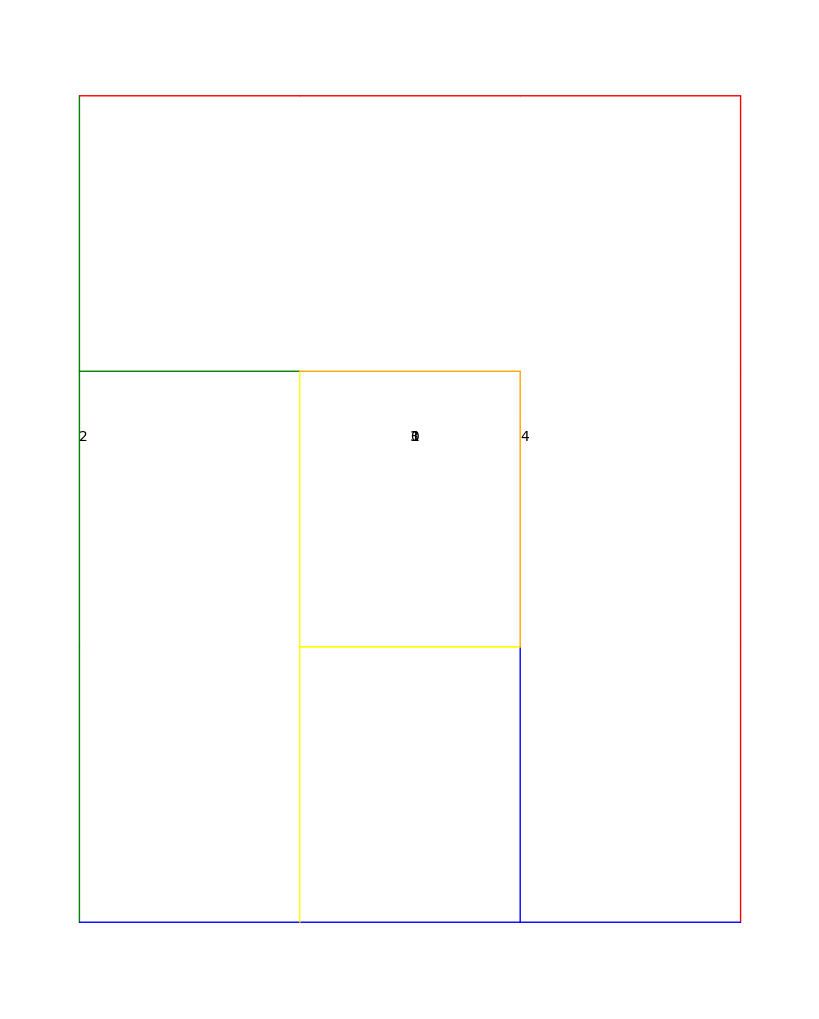

In [9]:
# エッジの作成（全てのノード間にパスがあるように設定）
edges = {
    'edge_1': ((0, 0), (0, 1)),
    'edge_2': ((0, 1), (0, 2)),
    'edge_3': ((0, 2), (0, 3)),
    'edge_4': ((0, 3), (1, 3)),
    'edge_5': ((1, 3), (2, 3)),
    'edge_6': ((2, 3), (3, 3)),
    'edge_7': ((3, 3), (3, 2)),
    'edge_8': ((3, 2), (3, 1)),
    'edge_9': ((3, 1), (3, 0)),
    'edge_10': ((3, 0), (2, 0)),
    'edge_11': ((2, 0), (1, 0)),
    'edge_12': ((1, 0), (0, 0)),
    'edge_13': ((1, 0), (1, 1)),
    'edge_14': ((1, 1), (1, 2)),
    'edge_15': ((1, 2), (2, 2)),
    'edge_16': ((2, 2), (2, 1)),
    'edge_17': ((2, 1), (1, 1)),
    'edge_18': ((1, 1), (2, 1)),
    'edge_19': ((2, 1), (2, 0)),
    'edge_20': ((1, 2), (0, 2))
}

# node_densityの設定（3つのクラスターに分かれるように設定）
node_density = {
    'edge_1': 100, 'edge_2': 120, 'edge_3': 90, # クラスター1
    'edge_4': 45, 'edge_5': 52, 'edge_6': 51, # クラスター2
    'edge_7': 56, 'edge_8': 53, 'edge_9': 44, # クラスター2
    'edge_10': 110, 'edge_11': 130, 'edge_12': 120, # クラスター1
    'edge_13': 9.0, 'edge_14': 9.8, 'edge_15': 11.0, # クラスター3
    'edge_16': 8, 'edge_17': 7.7, 'edge_18': 9.4, # クラスター3
    'edge_19': 120, 'edge_20': 110 # クラスター1
}

def calculate_NSk_total(clusters: list, S: nx.Graph):
    total_NSk = 0
    for i, A in enumerate(clusters):
        min_NSk = float('inf')
        for j, B in enumerate(clusters):
            if j in find_adjacent_clusters(clusters, S)[i]:
                NSk_A = calculate_NSk(A, B, S)
                if NSk_A < min_NSk:
                    min_NSk = NSk_A
        total_NSk += min_NSk
    total_NSk /= len(clusters)
    return total_NSk

def create_graph(edges):
    G = nx.MultiGraph()  # 起終点の重複したエッジを許可するためにMultiGraphを使用
    for edge_id, (start, end) in edges.items():
        if edge_id in node_density:
            G.add_weighted_edges_from([(start, end, node_density[edge_id])], weight='density', id=edge_id)
    return G

G = create_graph(edges)
print("Number of nodes in the networkx graph:", len(list(G.nodes)))
print("Number of edges in the networkx graph:", len(list(G.edges)))

def calculate_weight(d_u: float, d_v: float, sigma: float):
    # d_u = d_u/100 if d_u < 20 else 20/100
    # d_u = np.log(1+d_u)
    # d_v = d_v/100 if d_v < 20 else 20/100
    # d_v = np.log(1+d_u)
    
    weight = np.exp(-((d_u - d_v) ** 2)/sigma)
    
    return weight

# ライングラフ（エッジをノードにしたグラフ）を作成
def create_line_graph(G: nx.Graph):
    '''
    Create a line graph from a graph G. Line graph is a graph where the nodes represent the edges of the original graph G.
    
    Parameters
    ----------
    G : nx.Graph
        A graph object.
    
    Returns
    -------
    S : nx.Graph
        A line graph object.
    
    '''
    
    S = nx.line_graph(G) # line Graph
    for s,t,x in G.edges:
        S.nodes[(s,t,x)]['id'] = G.edges[(s,t,x)]['id']
        S.nodes[(s,t,x)]['density'] = G.edges[(s,t,x)]['density']

    # 全てのエッジにweightを追加する例
    for u, v, key, data in S.edges(keys=True, data=True):
        d_u = S.nodes[u]['density']
        d_v = S.nodes[v]['density']
        weight = calculate_weight(d_u, d_v, sigma=100)
        data['weight'] = weight  # ここで適切なweightを設定
    
    return S

S = create_line_graph(G)


weight_list = [S.get_edge_data(e[0], e[1])[0]['weight'] for e in S.edges]
print("weight mean:", np.mean(weight_list))
print("weight std:", np.std(weight_list))
pd.Series(weight_list).hist(bins=100)
plt.show()

pos = {node: (node[0], node[1]) for node in G.nodes()}

nx.draw(G, pos = pos, with_labels=True, node_size=40, font_size=8)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['density'] for u, v, d in G.edges(data=True)})
plt.show()

# 計算するクラスタ数
num_clusters = 5
# クラスタリングの実行
best_initial_clusters, max_initial_clusters, clusters_dict = recursive_bipartition(S, num_clusters, threshold=1)

# クラスタリング結果の表示
# ランダムにnum_desired_clusters個の色を選択
color_list = [
    'Red', 'Green', 'Blue', 'Yellow', 'Orange', 'Purple', 'Pink', 
    'Brown', 'Black', 'Gray', 'Cyan', 'Magenta', 'Lime', 
    'Maroon', 'Navy', 'Olive', 'Teal', 'Aqua', 'Silver'
]
colors = color_list[:num_clusters]
node_color_map = {}

for cluster_id, cluster in enumerate(best_initial_clusters):
    for node in cluster:
        node_color_map[node] = colors[cluster_id]

color_map = [node_color_map[edge] for edge in G.edges]

# ノードの位置を緯度経度に基づいて配置
pos = {node: (node[0], node[1]) for node in G.nodes()}

plt.figure(figsize=(8, 10))
nx.draw(G, pos, edge_color=color_map, with_labels=False, node_size=0, font_size=8)
# クラスター番号を記載
for i, cluster in enumerate(best_initial_clusters):
    print(f"cluster_{i}: {cluster}")
    cluster_x = sum([(node[0][0] + node[1][0])/2 for node in cluster])/len(cluster)
    cluster_y = sum([(node[0][1] + node[1][1])/2 for node in cluster])/len(cluster)
    plt.text(cluster_x, cluster_y, f"{i}", fontsize=10, color='black')

plt.show()

In [4]:
import os

max_length = max(len(cluster) for cluster in best_initial_clusters)
cluster_dict = {f"cluster_{i}": [G.edges[edge]['id'] for edge in cluster] + [None]*(max_length - len(cluster)) for i, cluster in enumerate(best_initial_clusters)}

df = pd.DataFrame(cluster_dict)
df.to_csv(f"/Users/masudasatoki/Desktop/cluster.csv", index=False)


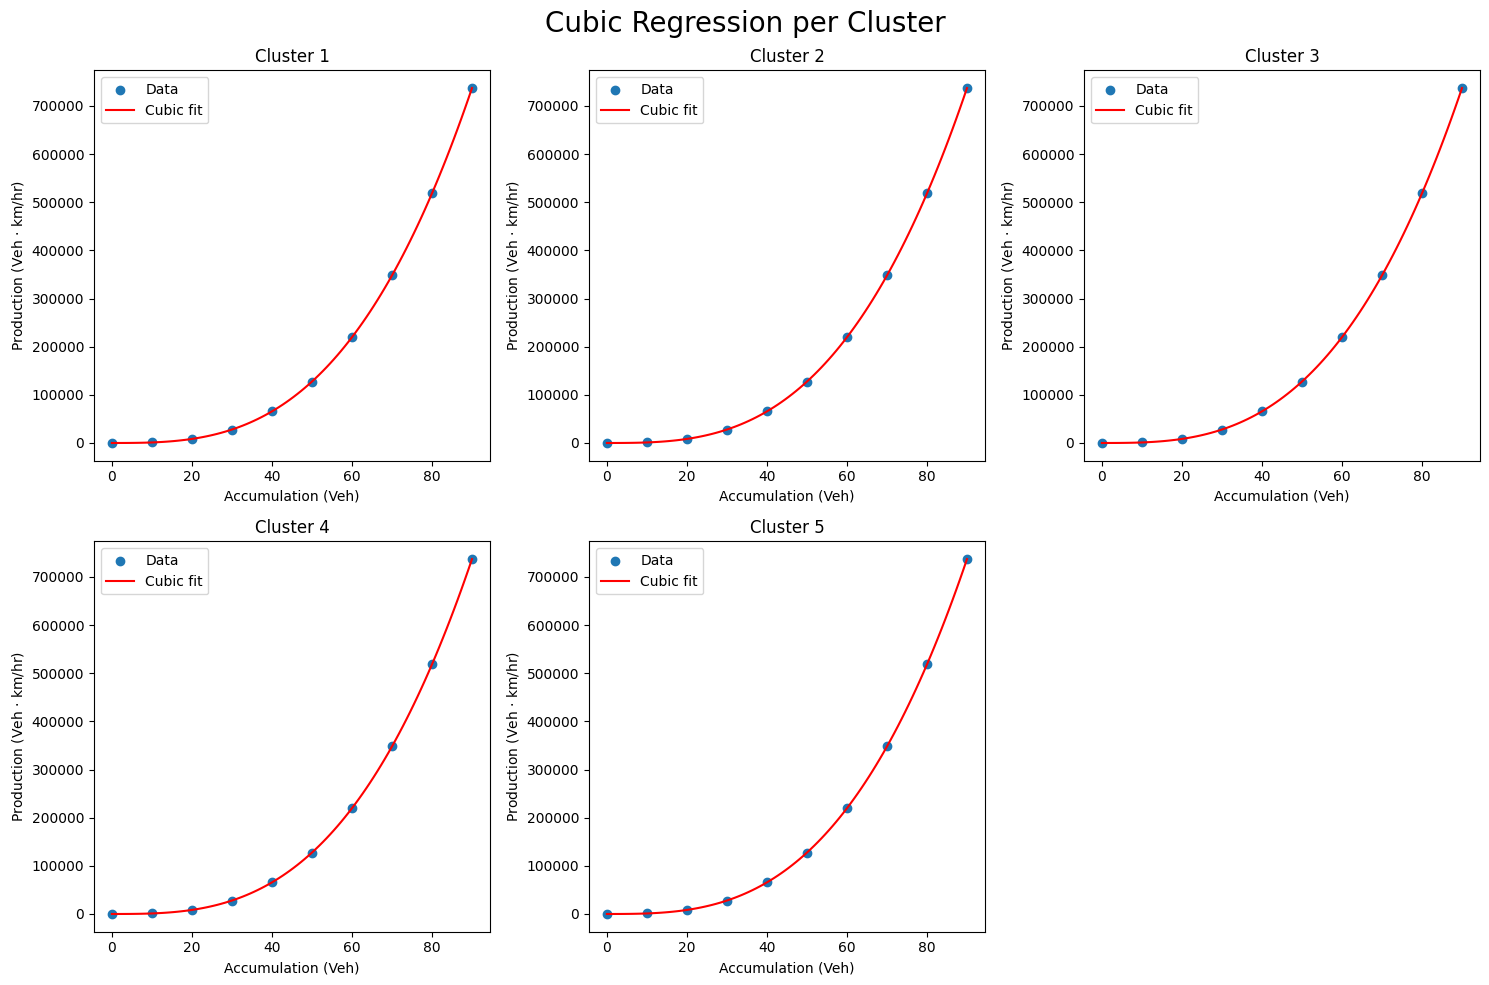

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

clusters = best_initial_clusters

cluster_accumulation = {i: [x for x in range(0, 100, 10)] for i in range(len(clusters))}
cluster_production = {i: [x**3 + x**2 +x for x in cluster_accumulation[i]] for i in range(len(clusters))}


num_clusters = len(clusters)
num_cols = 3
num_rows = (num_clusters + num_cols - 1) // num_cols
fig, ax = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
ax = ax.flatten()

params_list = []

for i in range(num_clusters):
    X = np.array(cluster_accumulation[i]).reshape(-1, 1)
    y = np.array(cluster_production[i])
    
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression(fit_intercept=False)
    model.fit(X_poly, y)
    
    X_fit = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_fit = model.predict(poly.transform(X_fit))
    
    ax[i].scatter(cluster_accumulation[i], cluster_production[i], label='Data')
    ax[i].plot(X_fit, y_fit, color='red', label='Cubic fit')
    ax[i].set_title(f'Cluster {i + 1}')
    ax[i].set_xlabel('Accumulation (Veh)')
    ax[i].set_ylabel(r'Production (Veh $\cdot$ km/hr)')
    ax[i].legend()
    
    # 回帰結果を保存
    df_regression_cluster = pd.DataFrame({
        'accumulation': cluster_accumulation[i],
        'production': cluster_production[i]
    })

    
    # 回帰パラメータを保存
    params_list.append([i] + model.coef_.tolist())

df_params = pd.DataFrame(params_list, columns=['cluster', 'coef1', 'coef2', 'coef3'])

for j in range(num_clusters, len(ax)):
    fig.delaxes(ax[j])

fig.suptitle('Cubic Regression per Cluster', fontsize=20)
plt.tight_layout()
plt.show()
